In [18]:
import pandas as pd
import os
import sys
from sklearn import set_config
from sklearn.model_selection import train_test_split
import numpy as np

sys.path.append(os.path.abspath(os.path.join("..")))
set_config(transform_output="pandas")

pancreatic = pd.read_csv("C:/My Work/Python/Machine Learning/Projects/Salivary Biomarker Research/data/processed/panc_filtered.csv")
lung = pd.read_csv("C:/My Work/Python/Machine Learning/Projects/Salivary Biomarker Research/data/processed/lung_filtered.csv")
gastric = pd.read_csv("C:/My Work/Python/Machine Learning/Projects/Salivary Biomarker Research/data/processed/gastric_filtered.csv")
breast = pd.read_csv("C:/My Work/Python/Machine Learning/Projects/Salivary Biomarker Research/data/processed/breast_filtered.csv")

In [19]:
from sklearn.preprocessing import QuantileTransformer

def process_and_harvest(df, test_size=0.2):
    X = df.drop(columns=["Cancer"])
    columns = X.columns
    X = pd.DataFrame(np.log1p(X), columns=columns)
    y = df["Cancer"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    healthy_train = X_train.loc[y_train == 0]
    cancer_train = X_train.loc[y_train == 1]

    return healthy_train, cancer_train, X_test, y_test

h_pan, c_pan, testX_pan, testY_pan = process_and_harvest(pancreatic)
h_lung, c_lung, testX_lung, testY_lung = process_and_harvest(lung)
h_gastric, c_gastric, testX_gastric, testY_gastric = process_and_harvest(gastric)
h_breast, c_breast, testX_breast, testY_breast = process_and_harvest(breast)

master_control = pd.concat([h_pan, h_lung, h_gastric, h_breast])

qt = QuantileTransformer(output_distribution="normal", random_state=42)
master_control = qt.fit_transform(master_control)

cancers_and_tests = [[c_pan, testX_pan], [c_lung, testX_lung], [c_gastric, testX_gastric], [c_breast, testX_breast]] 
for i in range(len(cancers_and_tests)):
    cancers_and_tests[i][0] = qt.transform(cancers_and_tests[i][0])
    cancers_and_tests[i][1] = qt.transform(cancers_and_tests[i][1])

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_data.py:2846: UserWarning: n_quantiles (1000) is greater than the total number of samples (50). n_quantiles is set to n_samples.
  warnings.warn(


In [20]:
y_train = pd.Series(np.zeros(master_control.shape[0]), name="Cancer")

In [21]:
from sklearn.utils import shuffle

def create_tr_X_and_y(control_df, cancer_df, y_control):
    X_tr = pd.concat([control_df, cancer_df], axis=0)
    y_cancer = pd.Series(np.ones(cancer_df.shape[0]), name="Cancer")
    y_tr = pd.concat([y_control, y_cancer], axis=0)
    X_shuffled, y_shuffled = shuffle(X_tr, y_tr, random_state=42)

    return X_shuffled, y_shuffled

X_train_pan, y_train_pan = create_tr_X_and_y(master_control, cancers_and_tests[0][0], y_train)
X_train_lung, y_train_lung = create_tr_X_and_y(master_control, cancers_and_tests[1][0], y_train)
X_train_gastric, y_train_gastric = create_tr_X_and_y(master_control, cancers_and_tests[2][0], y_train)
X_train_breast, y_train_breast = create_tr_X_and_y(master_control, cancers_and_tests[3][0], y_train)

In [22]:
from sklearn.linear_model import LassoCV

def lasso_reg(X_train, y_train, target_count=20):
    lasso = LassoCV(cv=5, random_state=42, max_iter=10000,  n_jobs=-1, verbose=1, tol=0.01)

    print("Starting LASSO regularisation...")
    lasso.fit(X_train, y_train)
    coef = pd.Series(lasso.coef_, index=X_train.columns)
    selected_features = coef[coef != 0].abs().sort_values(ascending=False)

    print(f"Done! Selected {len(selected_features)} features.")
    return selected_features.head(target_count).index.tolist()

In [23]:
X_train_pan = X_train_pan[lasso_reg(X_train_pan, y_train_pan)]
X_train_lung = X_train_lung[lasso_reg(X_train_lung, y_train_lung)]
X_train_gastric = X_train_gastric[lasso_reg(X_train_gastric, y_train_gastric)]
X_train_breast = X_train_breast[lasso_reg(X_train_breast, y_train_breast)]

testX_pan = testX_pan[X_train_pan.columns]
testX_lung = testX_lung[X_train_lung.columns]
testX_gastric = testX_gastric[X_train_gastric.columns]
testX_breast = testX_breast[X_train_breast.columns]

data = {
    "Pancreatic": [X_train_pan, testX_pan, y_train_pan, testY_pan],
    "Lung": [X_train_lung, testX_lung, y_train_lung, testY_lung],
    "Gastric": [X_train_gastric, testX_gastric, y_train_gastric, testY_gastric],
    "Breast": [X_train_breast, testX_breast, y_train_breast, testY_breast]
    }

print(f"Pancreatic genes:{X_train_pan.columns}")
print(f"Lung genes:{X_train_lung.columns}")
print(f"Gastric genes:{X_train_gastric.columns}")
print(f"Breast genes:{X_train_breast.columns}")

Starting LASSO regularisation...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
....................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   28.7s finished


Done! Selected 7 features.
Starting LASSO regularisation...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
....................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   17.8s finished


Done! Selected 272 features.
Starting LASSO regularisation...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
....................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   34.7s finished


Done! Selected 68 features.
Starting LASSO regularisation...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
...................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

Done! Selected 713 features.
Pancreatic genes:Index(['EAF2', 'IFNA8', 'ARL3', 'GFM1', 'USHBP1', 'PTGR1', 'LINC00311'], dtype='object')
Lung genes:Index(['BTBD19', 'CYP2A6', 'OR4D2', 'NLGN4Y', 'EXD1', 'LRRC17', 'TTLL12',
       'C19orf26', 'SOHLH2', 'PDE5A', 'LOC554174', 'CASP14', 'LOC100506107',
       'LOC644090', 'PDE8B', 'CYP19A1', 'C2orf61', 'TPBGL', 'TNRC6C',
       'FAM183CP'],
      dtype='object')
Gastric genes:Index(['CASP14', 'MMP27', 'MAGEA10', 'RP11-422P24.11', 'LOC283070',
       'RP11-355B11.2', 'CUEDC2', 'CAMSAP1', 'FAM178B', 'ADCY9', 'PRR15',
       'CAPNS2', 'RP11-53O19.3', 'CLPB', 'TJP2', 'CACNA1S', 'LOC101927379',
       'PGAP2', 'EDEM1', 'DNAJC30'],
      dtype='object')
Breast genes:Index(['EPHB3', 'RFC2', 'ESRRA', 'THRA', 'TMEM196', 'TTLL12', 'GUCA1A', 'PAX8',
       'SRSF12', 'PIGX', 'ALG10', 'CORO6', 'ARMCX4', 'GAPT', 'AK9', 'WFDC2',
       'CYP2E1', 'GSC', 'MBD3L2', 'AFG3L1P'],
      dtype='object')


.[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.6s finished


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

def create_pipeline(model, use_interactions=False):
    pipeline = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]

    if use_interactions:
        pipeline.append(("interactions", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)))
        pipeline.append(("feature_selection", SelectKBest(score_func=f_classif, k=5)))

    pipeline.append(("model", model))

    return Pipeline(pipeline)

models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForest": RandomForestClassifier()
}

In [25]:
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1"],
    "model__solver": ["liblinear"],
    "model__class_weight": ["balanced"]
}

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

param_grids = [lr_param_grid, rf_param_grid]

In [26]:
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
import numpy as np

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

def specificity_score(y_true, y_pred):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()

    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

scoring = {
    "recall": "recall",
    "specificity": make_scorer(specificity_score)
}

all_results = {}

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


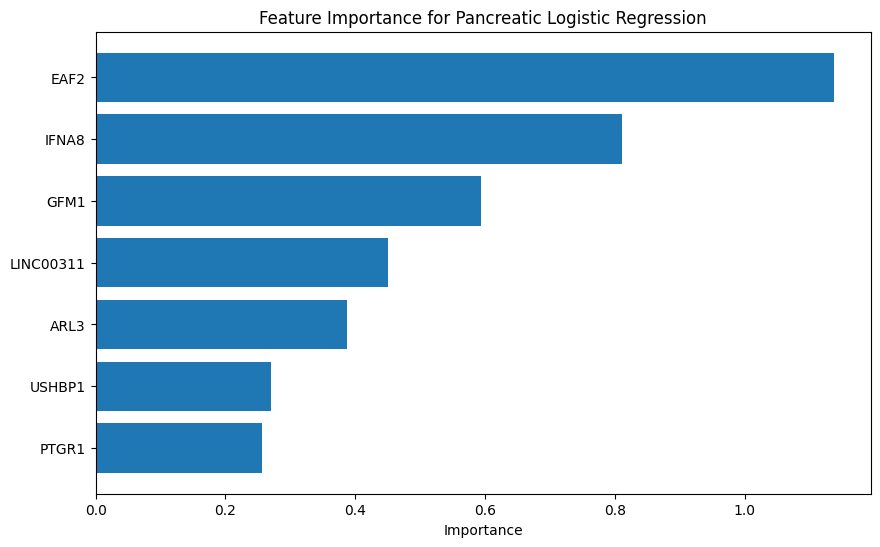

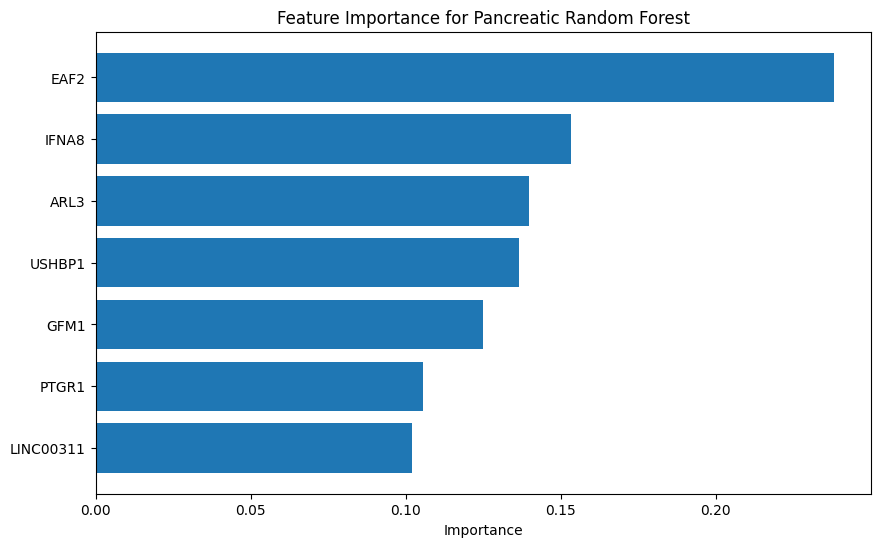

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Pancreatic Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       0.00      0.00      0.00         2

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5

Accuracy: 0.6000
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
Specificity: 1.0000

PancreaticRandom Forest Classification Report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       0.00      0.00      0.00         2

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5

Accuracy: 0.6000
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
Specificity: 1.0000



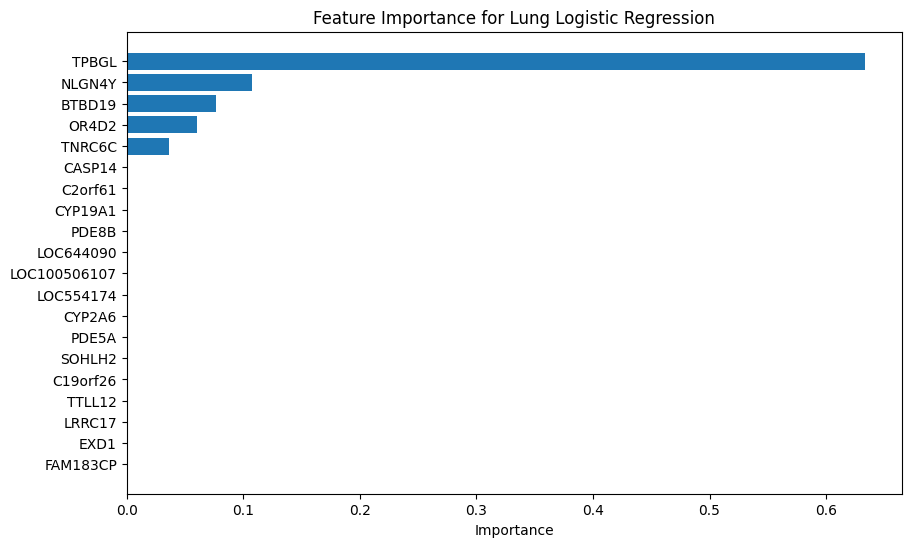

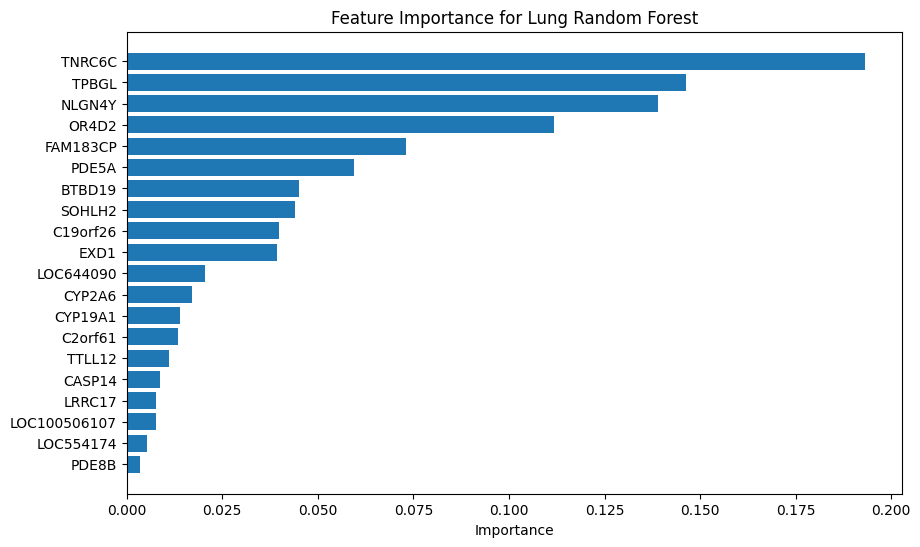

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Lung Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4

Accuracy: 0.5000
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
Specificity: 1.0000

LungRandom Forest Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4

Accuracy: 0.5000
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
Specificity: 1.0000



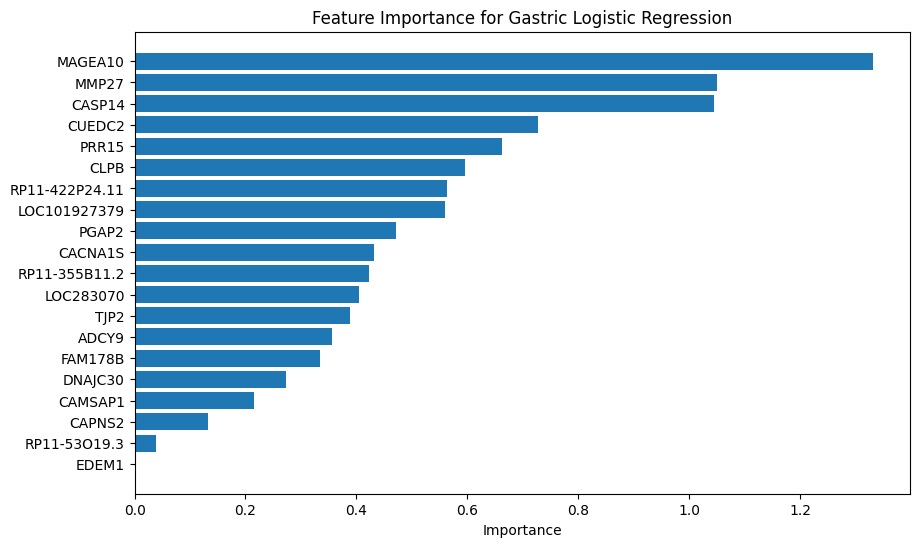

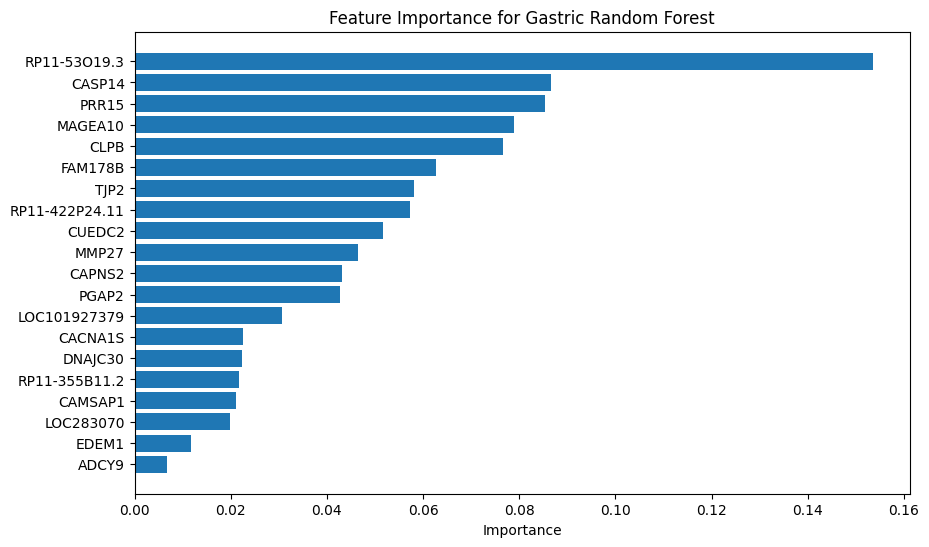

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Gastric Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.68      1.00      0.81        13

    accuracy                           0.68        19
   macro avg       0.34      0.50      0.41        19
weighted avg       0.47      0.68      0.56        19

Accuracy: 0.6842
Precision: 0.6842
Recall: 1.0000
F1: 0.8125
Specificity: 0.0000

GastricRandom Forest Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.68      1.00      0.81        13

    accuracy                           0.68        19
   macro avg       0.34      0.50      0.41        19
weighted avg       0.47      0.68      0.56        19

Accuracy: 0.6842
Precision: 0.6842
Recall: 1.0000
F1: 0.8125
Specificity: 0.0000



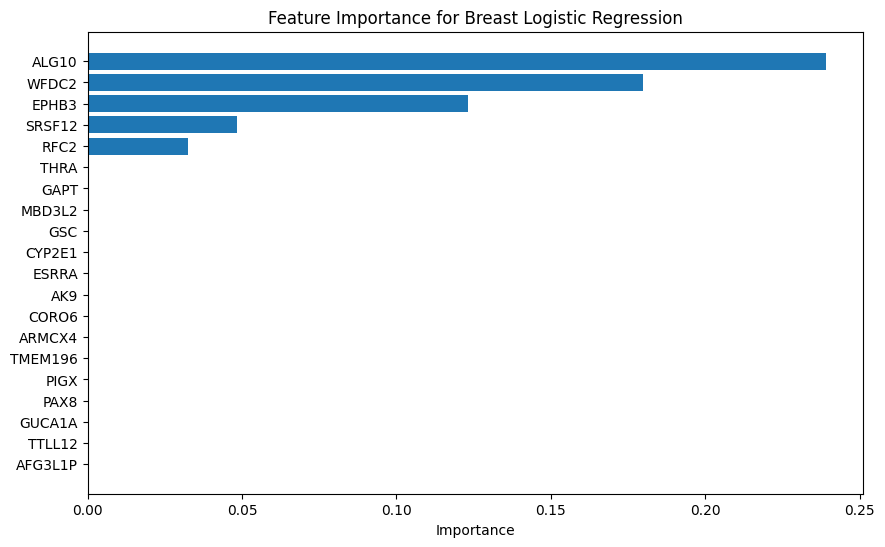

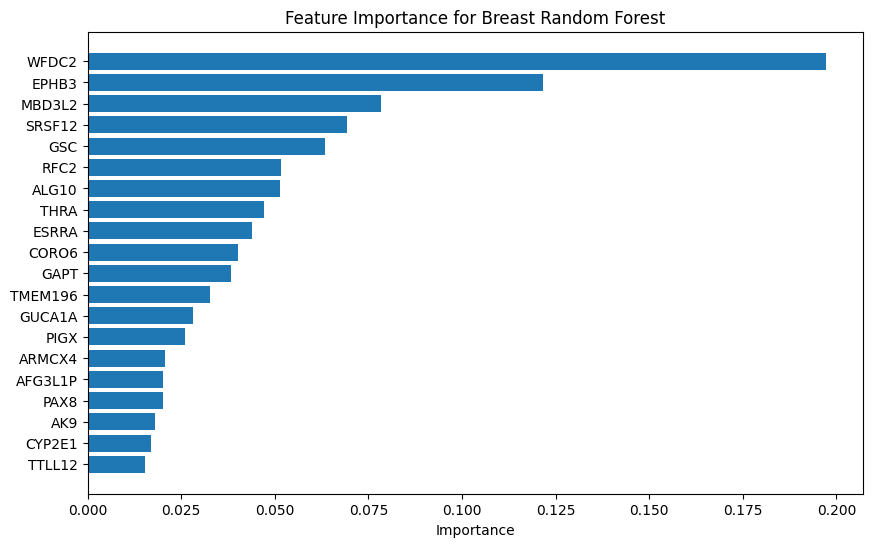

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Breast Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4

Accuracy: 0.5000
Precision: 0.5000
Recall: 1.0000
F1: 0.6667
Specificity: 0.0000

BreastRandom Forest Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4

Accuracy: 0.5000
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
Specificity: 1.0000



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, precision_score

def create_feat_importance_df(estimator):
    if hasattr(estimator.named_steps["model"], "coef_"):
        importances = np.abs(estimator.named_steps["model"].coef_[0])
    
    elif hasattr(estimator.named_steps["model"], "feature_importances_"):
        importances = estimator.named_steps["model"].feature_importances_
    
    if "interactions" in estimator.named_steps:
        feature_names = estimator.named_steps["interactions"].get_feature_names_out(X_train.columns)

        if "feature_selection" in estimator.named_steps:
            selector = estimator.named_steps["feature_selection"]
            feature_names = feature_names[selector.get_support()]

    else:
        feature_names = estimator.feature_names_in_          
    
    return pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

def create_feat_importance_graph(importance_df, model_name):
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.xlabel("Importance")
    plt.title(f"Feature Importance for {model_name}")
    plt.gca().invert_yaxis()
    plt.show()

unfitted_lr = []
unfitted_rf = []

for can_type, ind in data.items():
    lr_pipeline = create_pipeline(models["LogisticRegression"], use_interactions=False)
    rf_pipeline = create_pipeline(models["RandomForest"])
    pipelines = [lr_pipeline, rf_pipeline]

    for grid, model, pipeline in zip(param_grids, models.keys(), pipelines):
        search = RandomizedSearchCV(
            pipeline,
            param_distributions=grid, 
            n_iter=20,
            cv=cv, 
            scoring=scoring, 
            refit="recall",
            n_jobs=-1
        )
        search.fit(ind[0], ind[2])
        
        result = pd.DataFrame(search.cv_results_)
        best_rows = result.loc[result["mean_test_recall"].idxmax()]
        all_results[model] = best_rows

    lr_estimator = lr_pipeline.set_params(**all_results["LogisticRegression"]["params"])
    rf_estimator = rf_pipeline.set_params(**all_results["RandomForest"]["params"])

    unfitted_lr.append(lr_estimator)
    unfitted_rf.append(rf_estimator)

    lr_fitted = lr_estimator.fit(ind[0], ind[2])
    rf_fitted = rf_estimator.fit(ind[0], ind[2])

    lr_importance_df = create_feat_importance_df(lr_fitted)
    rf_importance_df = create_feat_importance_df(rf_fitted)

    create_feat_importance_graph(lr_importance_df, f"{can_type} Logistic Regression")
    create_feat_importance_graph(rf_importance_df, f"{can_type} Random Forest")

    y_pred_lr = lr_fitted.predict(ind[1])
    y_pred_rf = rf_fitted.predict(ind[1])

    print(f"{can_type} Logistic Regression Classification Report:\n"
        f"{classification_report(ind[3], y_pred_lr)}\n"
        f"Accuracy: {accuracy_score(ind[3], y_pred_lr):.4f}\n"
        f"Precision: {precision_score(ind[3], y_pred_lr):.4f}\n"
        f"Recall: {recall_score(ind[3], y_pred_lr):.4f}\n"
        f"F1: {f1_score(ind[3], y_pred_lr):.4f}\n"
        f"Specificity: {specificity_score(ind[3], y_pred_lr):.4f}\n"
       )

    print(f"{can_type} Random Forest Classification Report:\n"
        f"{classification_report(ind[3], y_pred_rf)}\n"
        f"Accuracy: {accuracy_score(ind[3], y_pred_rf):.4f}\n"
        f"Precision: {precision_score(ind[3], y_pred_rf):.4f}\n"
        f"Recall: {recall_score(ind[3], y_pred_rf):.4f}\n"
        f"F1: {f1_score(ind[3], y_pred_rf):.4f}\n"
        f"Specificity: {specificity_score(ind[3], y_pred_rf):.4f}\n"
        )

In [28]:
print("--- Average CV Performance (The Real Comparison) ---")
for model_name, results in all_results.items():
    print(f"{model_name}:")
    print(f"  Mean Recall: {results['mean_test_recall']:.4f}")
    print(f"  Mean Specificity: {results['mean_test_specificity']:.4f}")

--- Average CV Performance (The Real Comparison) ---
LogisticRegression:
  Mean Recall: 0.9000
  Mean Specificity: 0.6000
RandomForest:
  Mean Recall: 0.2333
  Mean Specificity: 0.9733


In [29]:
for model_name, best_rows in all_results.items():
    print(f"Model: {model_name}")

    fold_recall_scores = [best_rows[f"split{i}_test_recall"] for i in range(cv.get_n_splits(X_train, y_train))]
    fold_specificity_scores = [best_rows[f"split{i}_test_specificity"] for i in range(cv.get_n_splits(X_train, y_train))]

    print(f"Recall across folds: {np.round(fold_recall_scores, 2)}")
    print(f"Mean: {np.mean(fold_recall_scores):.2f} | Std Dev: {np.std(fold_recall_scores):.2f}")
    
    zeros = fold_recall_scores.count(0)
    if zeros > 0:
        print(f"⚠️ Warning: Model completely failed to find cancer in {zeros} out of {len(fold_recall_scores)} folds.")

Model: LogisticRegression


NameError: name 'X_train' is not defined

In [ ]:
# Instead of 0 or 1, let's look at the raw scores
y_probs_lr = lr_fitted.predict_proba(X_test)[:, 1]

print("--- Logistic Regression Prediction Confidence ---")
for i, prob in enumerate(y_probs_lr):
    actual = y_test.iloc[i].values[0]
    print(f"Patient {i+1}: Actual={actual}, Probability of Cancer={prob:.2f}")

--- Logistic Regression Prediction Confidence ---
Patient 1: Actual=1, Probability of Cancer=0.93
Patient 2: Actual=1, Probability of Cancer=0.10
Patient 3: Actual=0, Probability of Cancer=0.14
Patient 4: Actual=0, Probability of Cancer=0.08
Patient 5: Actual=0, Probability of Cancer=0.94


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_function_transformer.py:314: UserWarning: When `set_output` is configured to be 'pandas', `func` should return a pandas DataFrame to follow the `set_output` API  or `feature_names_out` should be defined.
  warnings.warn(warn_msg.format("pandas"))
